In [1]:
import BESplotting as bp

import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
import numpy as np
import sys

%matplotlib widget

-------------------Loading module Divertor-------------------
-------------------Loading module Utilities-------------------
kk_cz couldnt be imported (SyntaxError)
dd couldnt be imported


In [2]:
shotn = 50499
resultsFile = f'/home/sthoma/Documents/Results/rba/{shotn}/rba_results_1.npz'

In [3]:
results = np.load(resultsFile)

R = results['R']
# data = results['data']
# err = results['err']
time = results['time']
# Rgrid = results['Rgrid']
RgridB = results['RgridB']
# emissivity = results['emissivity']
# emissivityErr = results['emissivityErr']
# backprojection = results['backprojection']
# scale = results['scale']
emMax = results['emMax']
emMaxR = results['emMaxR']
# emR0 = results['emR0']
# emR1 = results['emR1']
emFWHM = results['emFWHM']
emFWHMerr = results['emFWHMerr']
# Rind = results['Rind']
Rprofile = results['Rprofile']
profileTemp = results['profileTemp']
profileDensity = results['profileDensity']
# ioniseRate = results['ioniseRate']
# ioniseErr = results['ioniseErr']
# neutralDensity = results['neutralDensity']
# neutralErr = results['neutralErr']
ioniseMax = results['ioniseMax']
ioniseMaxR = results['ioniseMaxR']
# ioniseR0 = results['ioniseR0']
# ioniseR1 = results['ioniseR1']
ioniseFWHM = results['ioniseFWHM']
ioniseFWHMerr = results['ioniseFWHMerr']
neutralMax = results['neutralMax']
neutralMaxR = results['neutralMaxR']
# neutralR1 = results['neutralR1']
# neutralR2 = results['neutralR2']
# neutralR3 = results['neutralR3']
neutralWidth1 = results['neutralWidth1']
neutralWidth1err = results['neutralWidth1err']
neutralWidth2 = results['neutralWidth2']
neutralWidth2err = results['neutralWidth2err']
neutralWidth3 = results['neutralWidth3']
neutralWidth3err = results['neutralWidth3err']
# neutralR1A = results['neutralR1A']
# neutralR2A = results['neutralR2A']
# neutralR3A = results['neutralR3A']
# neutralWidth1A = results['neutralWidth1A']
# neutralWidth1Aerr = results['neutralWidth1Aerr']
# neutralWidth2A = results['neutralWidth2A']
# neutralWidth2Aerr = results['neutralWidth2Aerr']
# neutralWidth3A = results['neutralWidth3A']
# neutralWidth3Aerr = results['neutralWidth3Aerr']
figN0 = results['figN0']
psiN = results['psiN']
neutralRatio = results['neutralRatio']

In [4]:
dar, dat = mf.getDalpha(shotn)
daUOSP, daUSXD, daLOSP, daLSXD = mf.getDalphaDivertor(shotn)

loading radial D-alpha
loaded /XIM/DA/HM10/R
loading tangential D-alpha
loaded /XIM/DA/HM10/T
loading upper OSP D-alpha
loaded /XIM/DA/HU10/OSP
loading upper SXD D-alpha
loaded /XIM/DA/HU10/SXD
loading lower OSP D-alpha
loaded /XIM/DA/HL02/OSP
loading upper SXD D-alpha
loaded /XIM/DA/HL02/SXD


In [39]:
t0 = 0.290
t1 = 0.959

In [40]:
def makeMask(tELMs, time, before=2e-3, after=5e-3):
    
    mask = np.ones_like(time).astype(bool)
    
    
    for i in range(0, len(tELMs)):
        twant = tELMs[i]
        t0 = fn.findNearest(time, twant-before)
        t1 = fn.findNearest(time, twant+after)+1
        mask[t0:t1] = False
        
        
    return mask

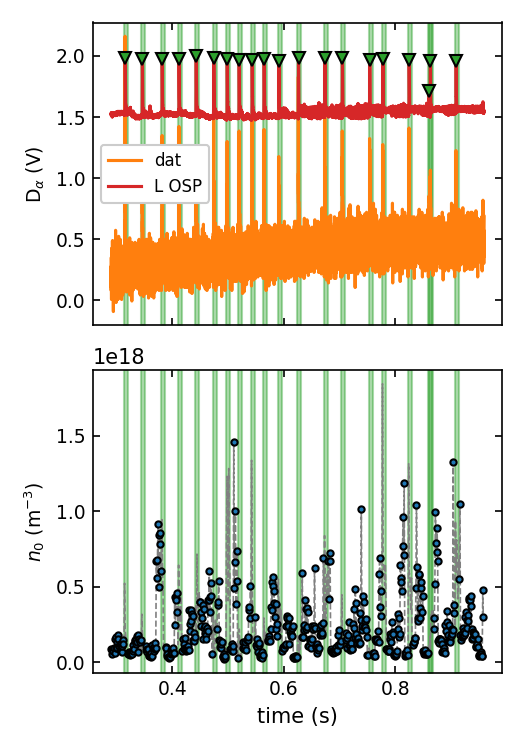

In [49]:
### make the cut down dalpha data
### time base
xalpha = daLOSP.time.data
dtAlpha = np.mean(np.diff(xalpha))
### find the time range and chop it down
tA = fn.findNearest(xalpha, t0)
tB = fn.findNearest(xalpha, t1)
### chop it down
xalpha = daLOSP.time.data[tA:tB]
yalpha = daLOSP.data[tA:tB]


### find the ELMs
bi, uc = mf.blob_detector(yalpha, mult=2.5, sep='limit')
tELMs = xalpha[bi]

### specify the time before and after the ELM to exclude
before = 2e-3
after = 5e-3
### indices for plotting dalpha
beforeAlpha = int(before / dtAlpha)
afterAlpha = int(after / dtAlpha)

### make the dAlpha mask
maskAlpha = makeMask(tELMs, xalpha, before=before, after=after)


### chopped down the neutral data 
tind0 = fn.findNearest(time, t0)
tind1 = fn.findNearest(time, t1)
### 
xn0 = time[tind0:tind1]
dtn0 = np.mean(np.diff(time))
yn0 = neutralMax[tind0:tind1]
### indices for plotting n0
# beforen0 = int(before / dtn0)
# aftern0 = int(after / dtn0)
### make the n0 mask
maskn0 = makeMask(tELMs, xn0, before, after)


### plot the data
fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150, sharex=True)

### dalpha
# ax[0].plot(dar.time.data[tA:tB], dar.data[tA:tB]*8., c='C0', label='dar')
ax[0].plot(dat.time.data[tA:tB], dat.data[tA:tB]*40., c='C1', label='dat')
# ax[0].plot(daUOSP.time.data[tA:tB], daUOSP.data[tA:tB], c='C4', label='U OSP')
# ax[0].plot(daUSXD.time.data[tA:tB], daUSXD.data[tA:tB], c='C5', label='U SXD')
# ax[0].plot(daLSXD.time.data[tA:tB], daLSXD.data[tA:tB], c='C6', label='L SXD')
ax[0].plot(xalpha, yalpha, c='C3', label='L OSP')
# ax[0].plot(xalpha[maskAlpha], yalpha[maskAlpha], '.', c='C0')
ax[0].plot(tELMs, yalpha[bi], 'v', c='C2', mec='k')
### limit
xlim0 = ax[0].get_xlim()
ylim0 = ax[0].get_ylim()
ax[0].set_xlim(xlim0)
ax[0].set_ylim(ylim0)
### ELM fillbetween
for i in range(0, len(bi)):
    x0 = xalpha[bi[i]-beforeAlpha]
    x1 = xalpha[bi[i]+afterAlpha]
    ax[0].fill_between([x0,x1], [ylim0[0],ylim0[0]], [ylim0[1],ylim0[1]], color='C2', alpha=0.4)
### some options
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
# ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('D$_\\alpha$ (V)', fontsize=9)

### n0
ax[1].plot(xn0, yn0, '--', c='gray', lw=0.8)
ax[1].plot(xn0[maskn0], yn0[maskn0], '.', c='C0', mec='k')
### limit
xlim1 = ax[1].get_xlim()
ylim1 = ax[1].get_ylim()
ax[1].set_xlim(xlim1)
ax[1].set_ylim(ylim1)
# ### ELM fillbetween
for i in range(0, len(bi)):
    x0 = xalpha[bi[i]-beforeAlpha]
    x1 = xalpha[bi[i]+afterAlpha]
    ax[1].fill_between([x0,x1], [ylim1[0],ylim1[0]], [ylim1[1],ylim1[1]], color='C2', alpha=0.4)
### some options
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)

plt.tight_layout()

In [30]:
bi[i]

3512

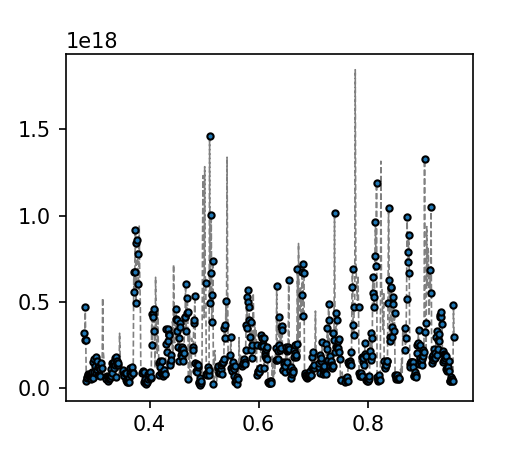

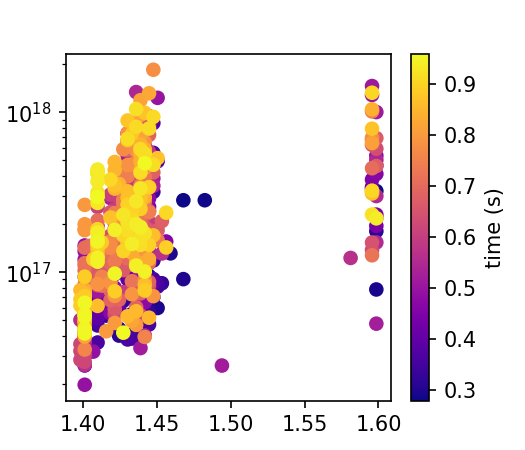

In [21]:



fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(xn0, yn0, '--', c='gray', lw=0.8)
ax.plot(xn0[maskn0], yn0[maskn0], '.', c='C0', mec='k')





fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
sc=ax.scatter(
    neutralMaxR[tind0:tind1], neutralMax[tind0:tind1], 
    c=time[tind0:tind1], cmap=plt.cm.plasma
)
cbar=fig.colorbar(sc, ax=ax, label='time (s)')
ax.set_yscale('log')



In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
# ax.plot(dar.time.data, dar.data, c='C0', label='Radial')
# ax.plot(dat.time.data, dat.data, c='C1', label='Tang.')
# ax.plot(daUOSP.time.data, daUOSP.data, c='C2', label='U OSP')
ax.plot(daLOSP.time.data, daLOSP.data, c='C3', label='L OSP')
# ax.plot(daUSXD.time.data, daUSXD.data, c='C4', label='U SXD')
# ax.plot(daLSXD.time.data, daLSXD.data, c='C5', label='L SXD')

ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('time (s)')
ax.set_ylabel('D$_\\alpha$ (V)')
ax.set_xlim([-0.1,1.3])
plt.tight_layout()

In [ ]:
bp.subplotsBES(shotn)

In [ ]:
time

In [ ]:
shotn, time[-1]

In [ ]:
bp.plotSXR(shotn, )

In [ ]:
thomsonTime, ne, neErr, Rthomson = HSV.getThomson(shotn, 'n_e')
_, Te, TeErr, _ = HSV.getThomson(shotn, 'T_e')

In [ ]:
thomsonTime[i], time

In [ ]:
rind = HSV.findNearest(Rprofile, 1.25)
Rprofile[rind:]

In [ ]:
Te[I,rind:][np.isfinite(Te[I,rind:])]

In [ ]:
i = 200
I = HSV.findNearest(thomsonTime, time[i])
rind = HSV.findNearest(Rthomson[I], 1.25)

fig, ax = plt.subplots(1, 2, figsize=(5,3), dpi=150, sharex=True)

ax[0].errorbar(Rthomson[I], ne[I], yerr=neErr[I], c='C0', fmt='None', capsize=4)
ax[0].plot(Rprofile, profileDensity[i], '--k')
ax[0].set_xlabel('$R$ (m)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_ylim([0, ne[I,rind:][np.isfinite(ne[I,rind:])].max()*1.1])

ax[1].errorbar(Rthomson[I], Te[I], yerr=TeErr[I], c='C3', fmt='None', capsize=4)
ax[1].plot(Rprofile, profileTemp[i], '--k')
ax[1].set_xlabel('$R$ (m)')
ax[1].set_ylabel('$T_e$ (eV)')
ax[1].set_ylim([0, Te[I,rind:][np.isfinite(Te[I,rind:])].max()*1.1])

ax[0].set_xlim([1.25, 1.50])

fig.suptitle(f'shot # {shotn}, t={time[i]:.4f}s')
plt.tight_layout()

In [ ]:
from importlib import reload
reload(HSV)

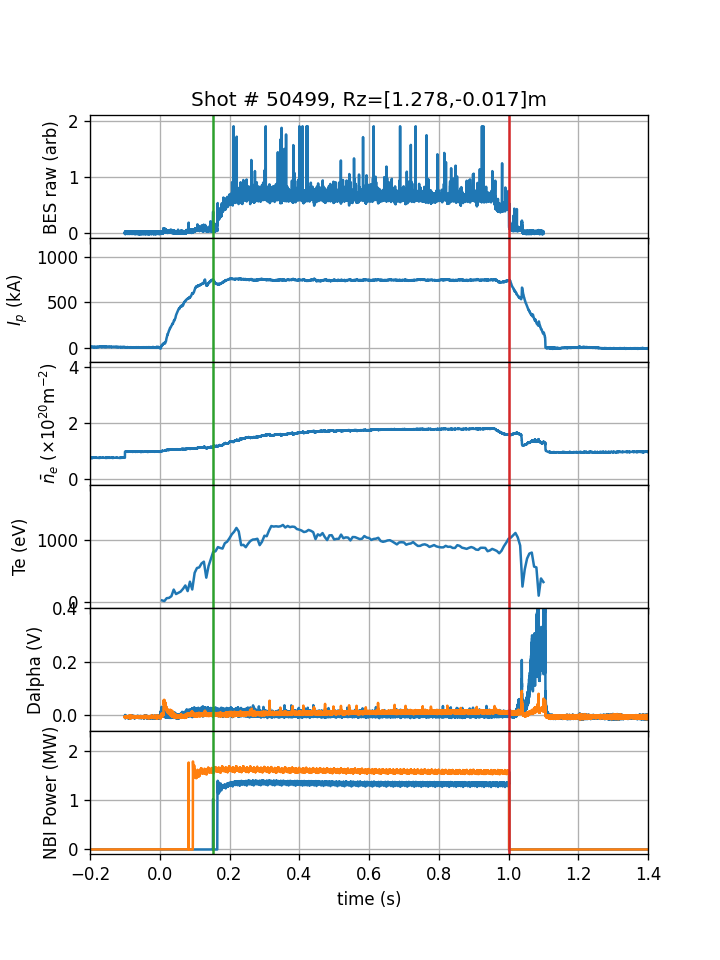

In [53]:
bp.subplotsBES(50499)

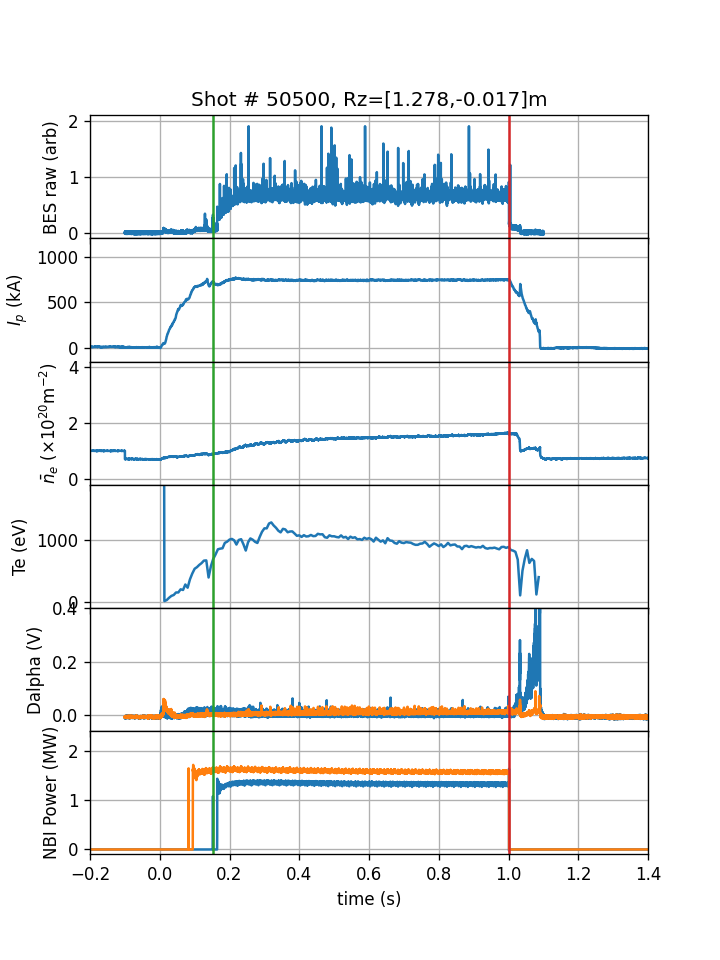

In [54]:
bp.subplotsBES(50500)

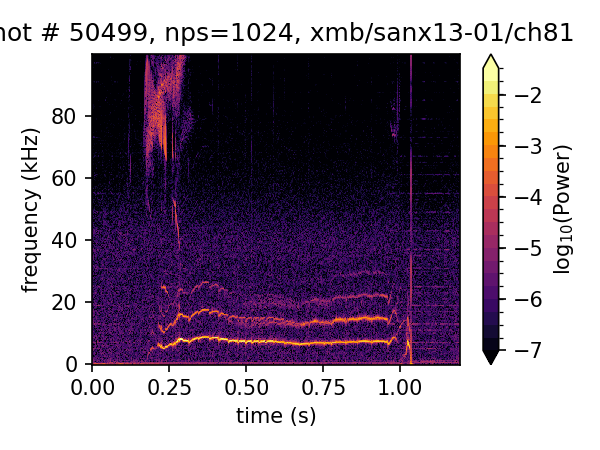

In [51]:
bp.plotSXR(50499, )

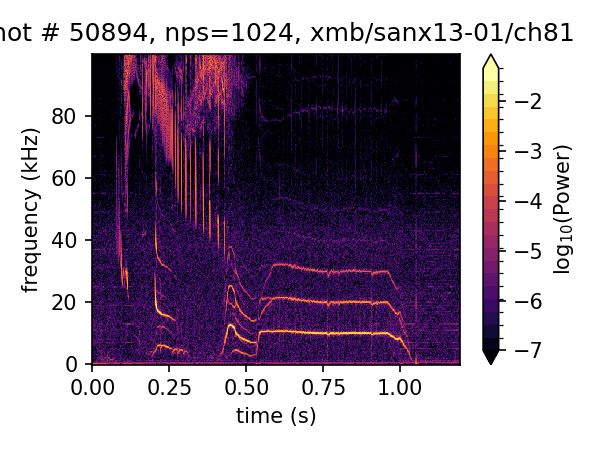

In [52]:
bp.plotSXR(50894, )